# 2 EDA: how features relate to price
Uses the cleaned data from `data_cleaning.ipynb` (`data/vehicles_clean.csv`).
Categories are ordered by median price. Gray boxes are placeholder groups (`unknown`, `missing`, `other`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

df = pd.read_csv("data/vehicles_clean.csv")

# chart style: one accent colour, gray for placeholder groups, quiet axes
ACCENT = "#2a78d6"
MUTED = "#b8b7b1"
INK = "#0b0b0b"
INK2 = "#52514e"
PLACEHOLDERS = {"unknown", "missing", "other"}

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK2,
    "axes.titlecolor": INK,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.grid": True,
    "grid.color": "#e6e5e0",
    "grid.linewidth": 0.8,
    "xtick.color": INK2,
    "ytick.color": INK2,
    "font.size": 10,
})
dollars = mtick.FuncFormatter(lambda x, _: f"${x / 1000:,.0f}k")
df.shape

(205385, 30)

## Target: price
Raw price is right-skewed (a long tail of expensive cars). On a log scale it's close to symmetric, which is why the model will train on `log1p(price)`.

skew raw: 2.32   skew log: -0.31


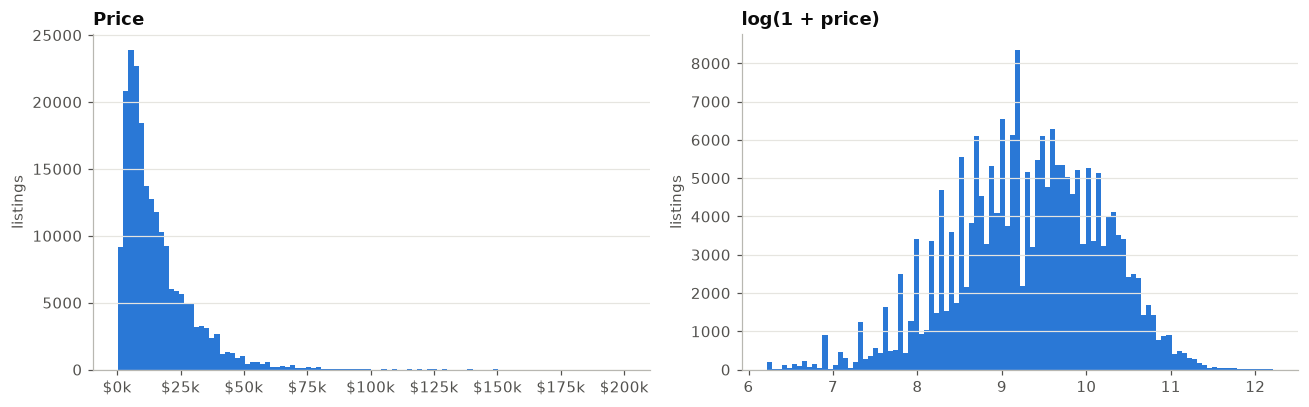

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

axes[0].hist(df["price"], bins=100, color=ACCENT)
axes[0].set_title("Price")
axes[0].xaxis.set_major_formatter(dollars)
axes[0].set_ylabel("listings")

axes[1].hist(np.log1p(df["price"]), bins=100, color=ACCENT)
axes[1].set_title("log(1 + price)")
axes[1].set_ylabel("listings")

for ax in axes:
    ax.grid(axis="x", visible=False)
plt.tight_layout()
print(f"skew raw: {df['price'].skew():.2f}   skew log: {np.log1p(df['price']).skew():.2f}")

## Numeric features: year and odometer
205k points would be an unreadable scatter, so these show the **median price** per year / per 10k miles, with the band covering the middle 50% of listings (25th–75th percentile).

          price  year  odometer
price      1.00  0.70     -0.61
year       0.70  1.00     -0.64
odometer  -0.61 -0.64      1.00


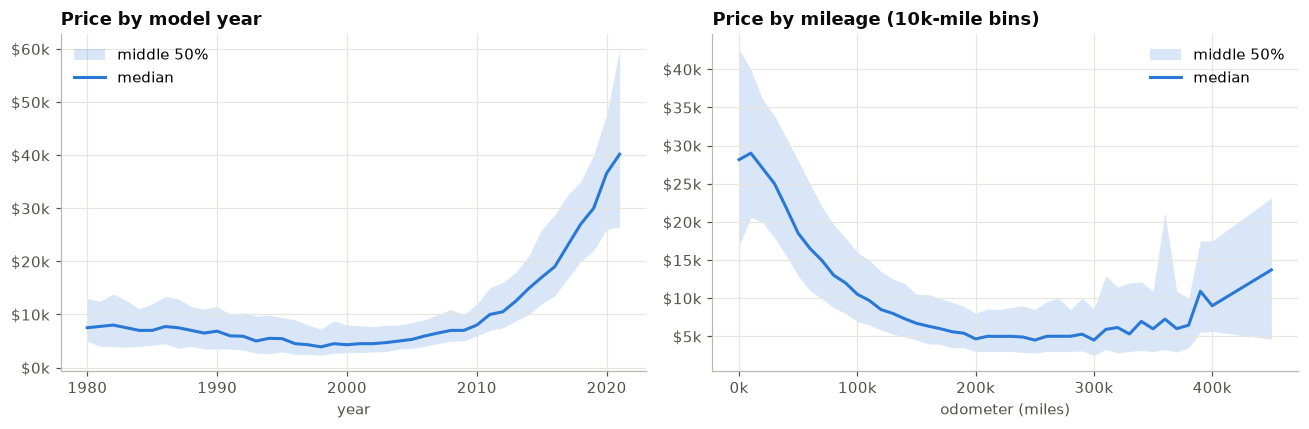

In [3]:
def median_band(ax, x, title, xlabel):
    g = df.groupby(x)["price"]
    stats = pd.DataFrame({"median": g.median(), "q25": g.quantile(0.25),
                          "q75": g.quantile(0.75), "n": g.size()})
    stats = stats[stats["n"] >= 30]  # skip thin groups
    ax.fill_between(stats.index, stats["q25"], stats["q75"], color=ACCENT, alpha=0.18, linewidth=0,
                    label="middle 50%")
    ax.plot(stats.index, stats["median"], color=ACCENT, linewidth=2, label="median")
    ax.yaxis.set_major_formatter(dollars)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend(frameon=False, loc="upper left")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
median_band(axes[0], "year", "Price by model year", "year")

odo_bin = (df["odometer"] // 10_000 * 10_000).rename("odometer_10k")
df_odo = df.assign(odometer_10k=odo_bin)
g = df_odo.groupby("odometer_10k")["price"]
stats = pd.DataFrame({"median": g.median(), "q25": g.quantile(0.25), "q75": g.quantile(0.75), "n": g.size()})
stats = stats[stats["n"] >= 30]
axes[1].fill_between(stats.index, stats["q25"], stats["q75"], color=ACCENT, alpha=0.18, linewidth=0, label="middle 50%")
axes[1].plot(stats.index, stats["median"], color=ACCENT, linewidth=2, label="median")
axes[1].yaxis.set_major_formatter(dollars)
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x / 1000:,.0f}k"))
axes[1].set_title("Price by mileage (10k-mile bins)")
axes[1].set_xlabel("odometer (miles)")
axes[1].legend(frameon=False, loc="upper right")
plt.tight_layout()

print(df[["price", "year", "odometer"]].corr(method="spearman").round(2))

## Categorical features
Box = middle 50% of prices, line = median, whiskers = typical range (outliers hidden). The x-axis is log scale so cheap and expensive groups are both readable. `n` is the number of listings.

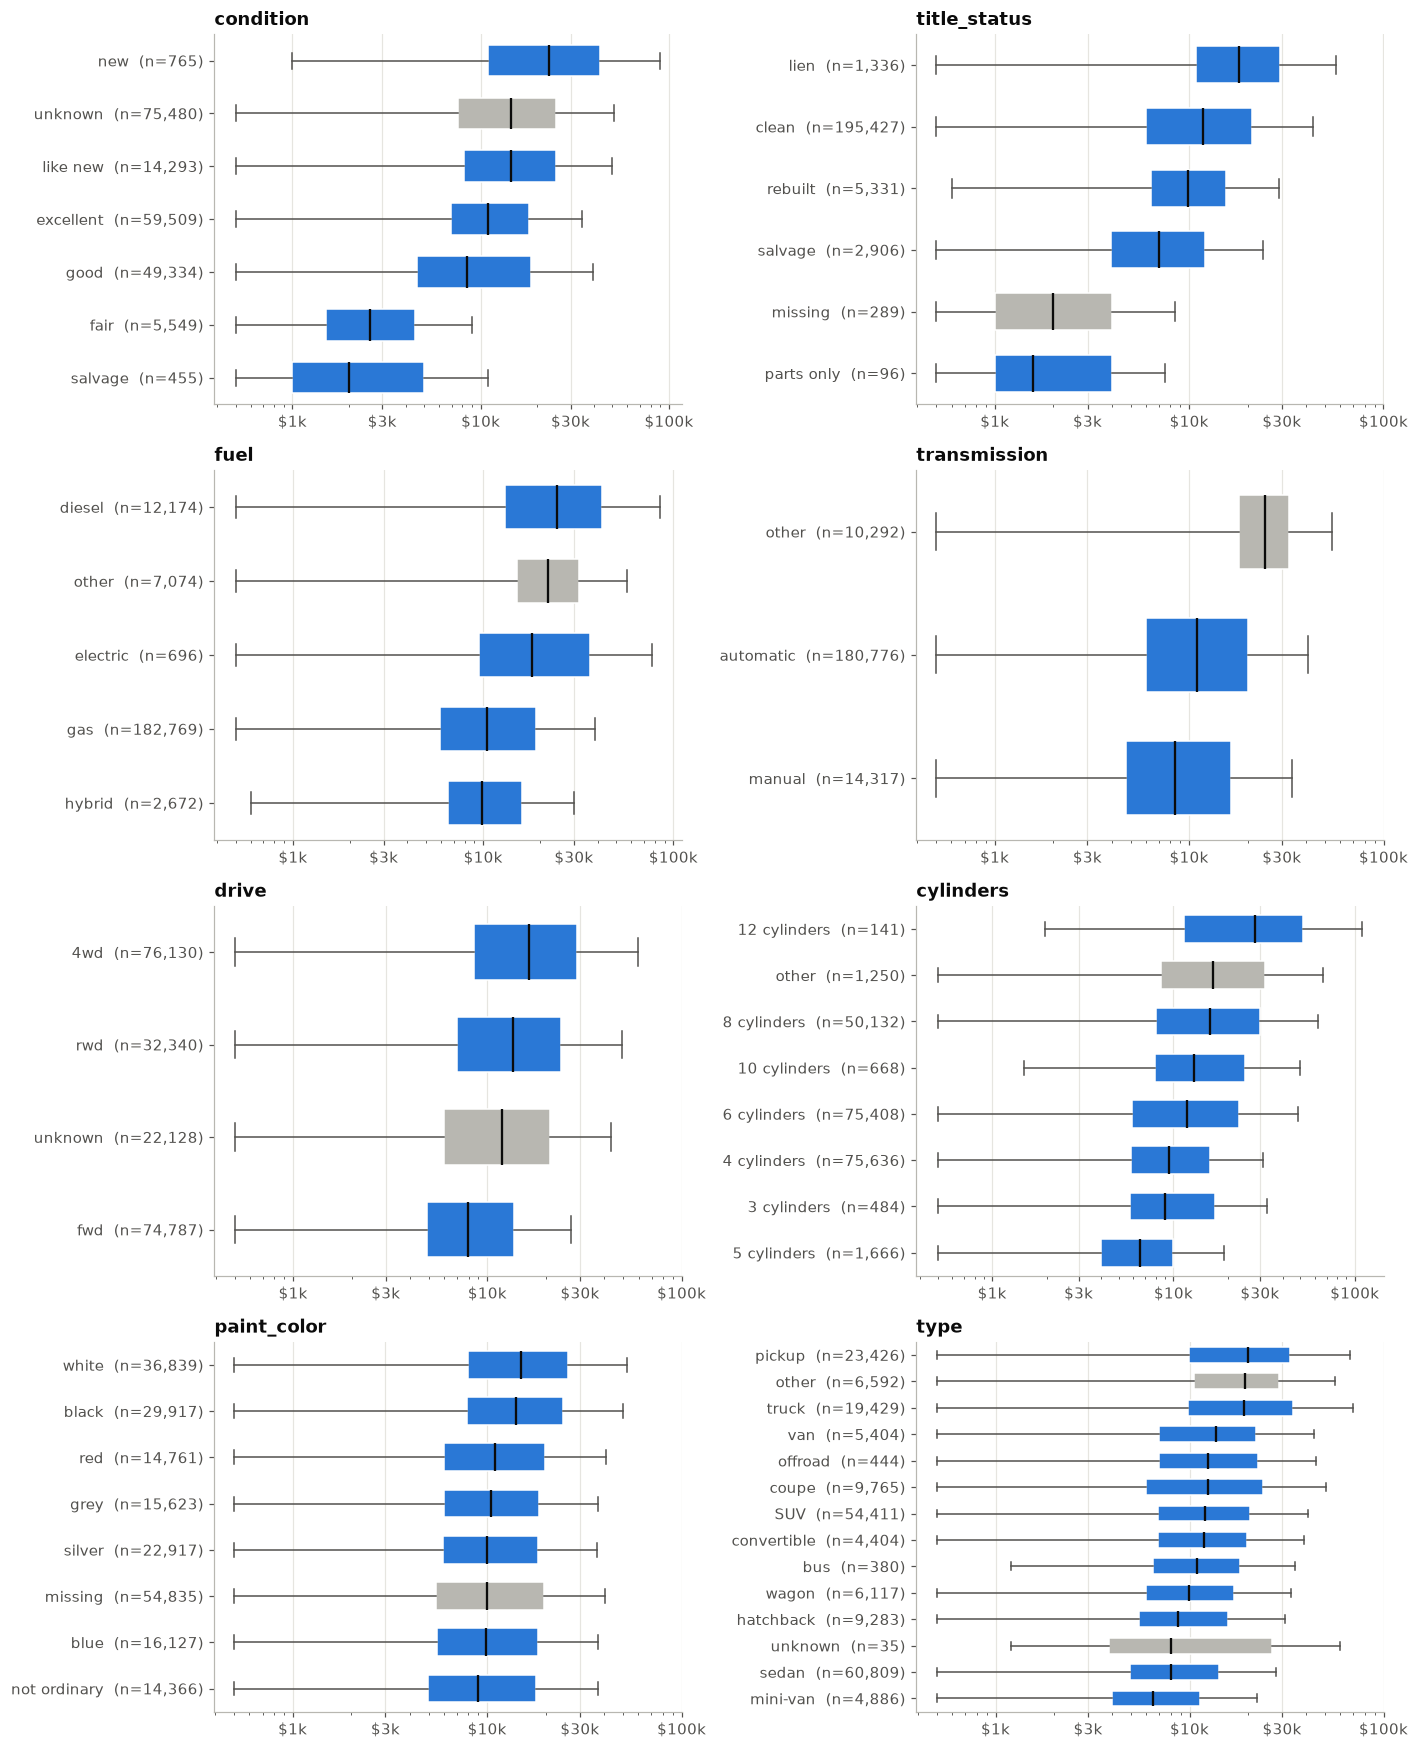

In [4]:
def price_boxes(ax, col, top=None, min_count=30):
    counts = df[col].value_counts()
    keep = counts[counts >= min_count]
    if top:
        keep = keep.head(top)
    order = df[df[col].isin(keep.index)].groupby(col)["price"].median().sort_values().index
    data = [df.loc[df[col] == k, "price"] for k in order]

    bp = ax.boxplot(data, orientation="horizontal", showfliers=False, widths=0.6, patch_artist=True,
                    medianprops={"color": INK, "linewidth": 1.5},
                    whiskerprops={"color": INK2}, capprops={"color": INK2})
    for box, k in zip(bp["boxes"], order):
        box.set_facecolor(MUTED if str(k) in PLACEHOLDERS else ACCENT)
        box.set_edgecolor("white")
    ax.set_yticks(range(1, len(order) + 1), [f"{k}  (n={keep[k]:,})" for k in order])
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(dollars)
    ax.xaxis.set_minor_formatter(mtick.NullFormatter())
    ax.set_xticks([1_000, 3_000, 10_000, 30_000, 100_000])
    ax.grid(axis="y", visible=False)
    ax.set_title(col)

small = ["condition", "title_status", "fuel", "transmission", "drive", "cylinders", "paint_color", "type"]
fig, axes = plt.subplots(4, 2, figsize=(13, 16))
for ax, col in zip(axes.flat, small):
    price_boxes(ax, col)
plt.tight_layout()

## Manufacturer and model
Only the 25 most common manufacturers / models are shown.

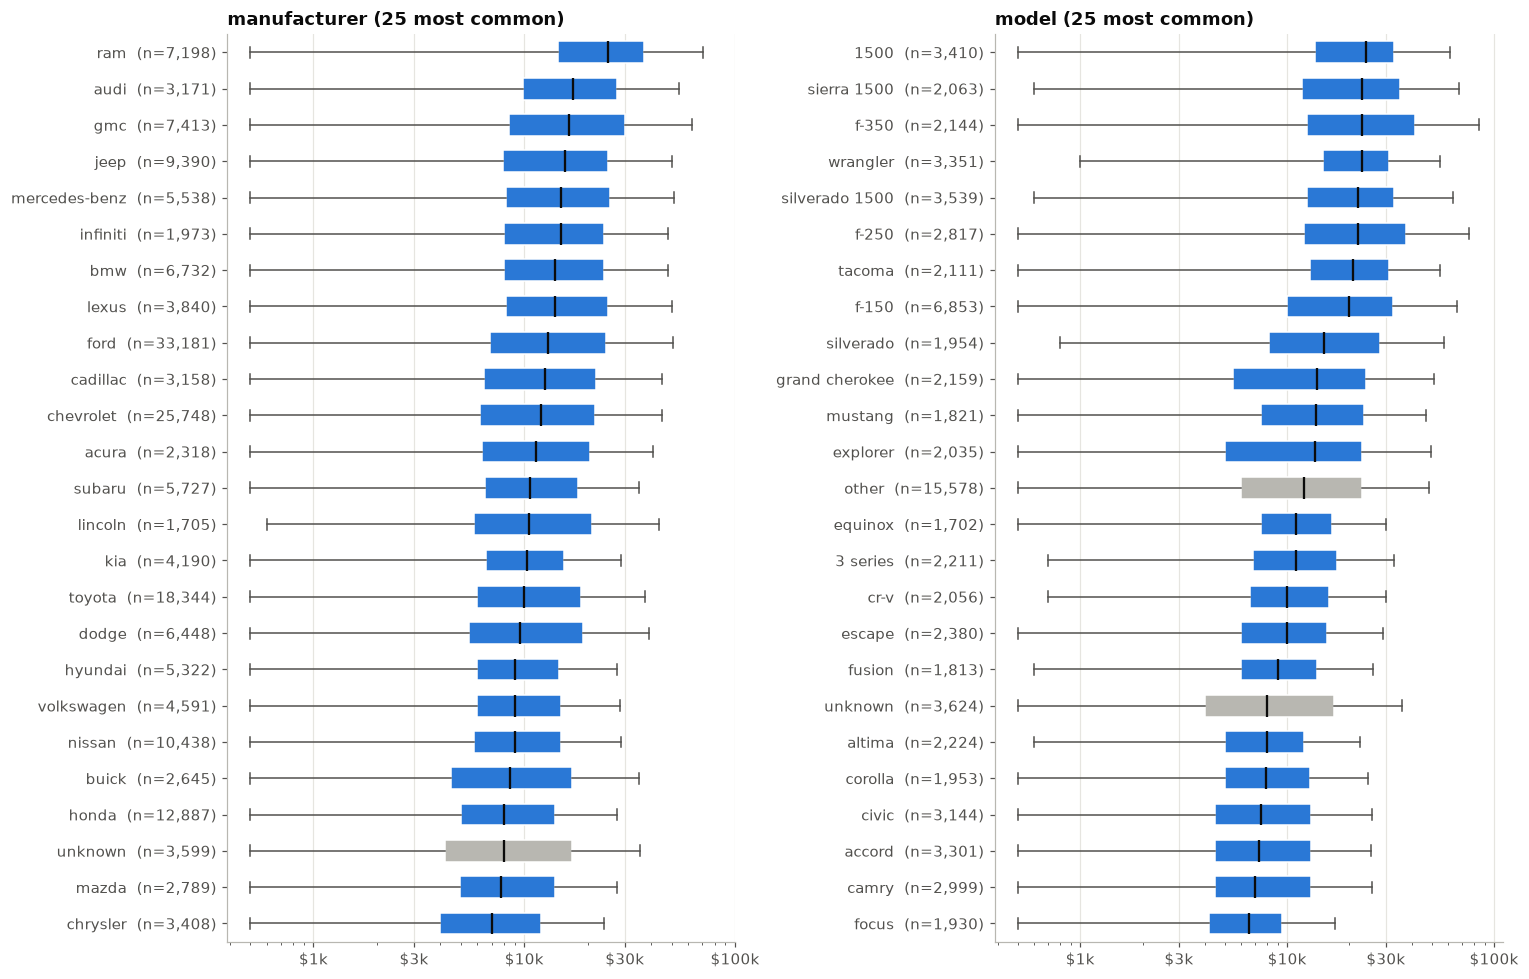

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 9))
price_boxes(axes[0], "manufacturer", top=25)
price_boxes(axes[1], "model", top=25)
axes[1].set_title("model (25 most common)")
axes[0].set_title("manufacturer (25 most common)")
plt.tight_layout()

## State
Median price per state. Location has a real but much smaller effect than year, mileage or vehicle type.

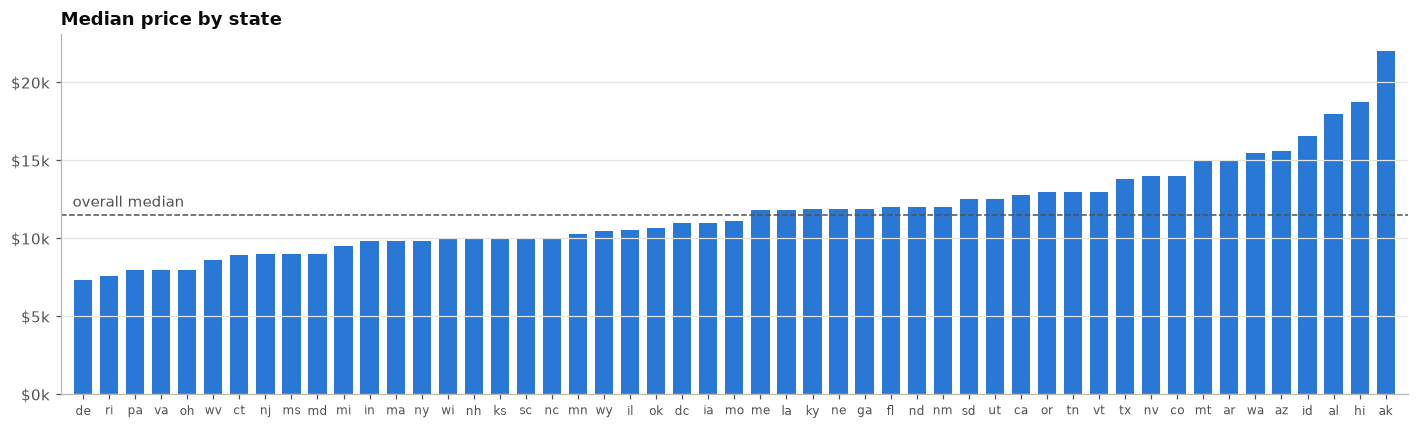

In [6]:
state = df.groupby("state")["price"].agg(["median", "size"]).sort_values("median")
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(state.index, state["median"], color=ACCENT, width=0.7)
ax.axhline(df["price"].median(), color=INK2, linewidth=1, linestyle="--")
ax.text(-0.4, df["price"].median() + 300, "overall median", va="bottom", ha="left", color=INK2)
ax.yaxis.set_major_formatter(dollars)
ax.set_title("Median price by state")
ax.tick_params(axis="x", labelsize=8)
ax.grid(axis="x", visible=False)
ax.margins(x=0.01)
plt.tight_layout()

## How strong is each feature?
A quick single-feature check: how much of the variance in `log(price)` does each feature explain on its own (grouping by category, or by year / 10k-mile bin for the numeric ones). This ignores interactions, so treat it as a ranking, not a final answer.

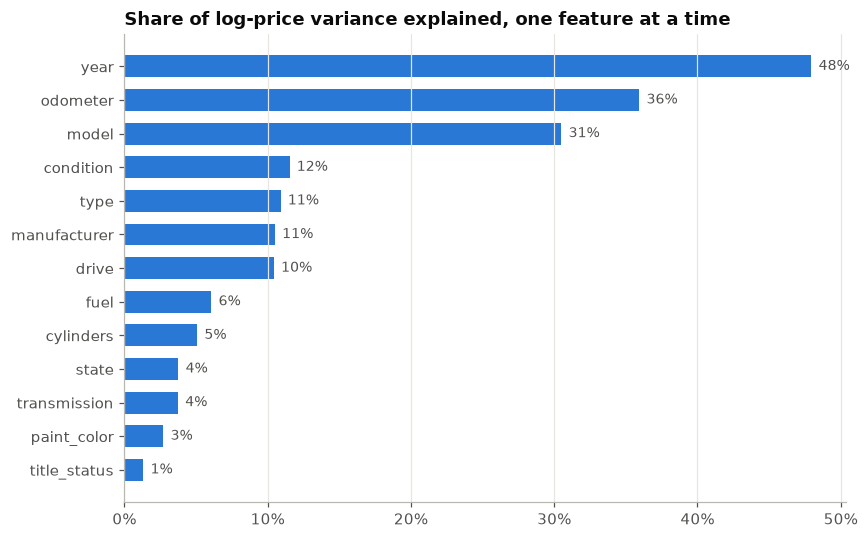

In [7]:
log_price = np.log1p(df["price"])
total_var = log_price.var()
features = small + ["manufacturer", "model", "state"]
groups = {c: df[c] for c in features}
groups["year"] = df["year"]
groups["odometer"] = df["odometer"] // 10_000

explained = {name: 1 - (log_price - log_price.groupby(key).transform("mean")).var() / total_var
             for name, key in groups.items()}
explained = pd.Series(explained).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(explained.index, explained.values, color=ACCENT, height=0.65)
for y, v in enumerate(explained.values):
    ax.text(v + 0.005, y, f"{v:.0%}", va="center", color=INK2, fontsize=9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Share of log-price variance explained, one feature at a time")
ax.grid(axis="y", visible=False)
plt.tight_layout()

# Correlations and heatmaps

## Numeric correlation
Pearson measures straight-line relationships; Spearman measures any steady up/down relationship (rank-based), which suits price better because it isn't linear in year or mileage. `cylinders_num` is the number pulled out of `cylinders` ("6 cylinders" → 6).

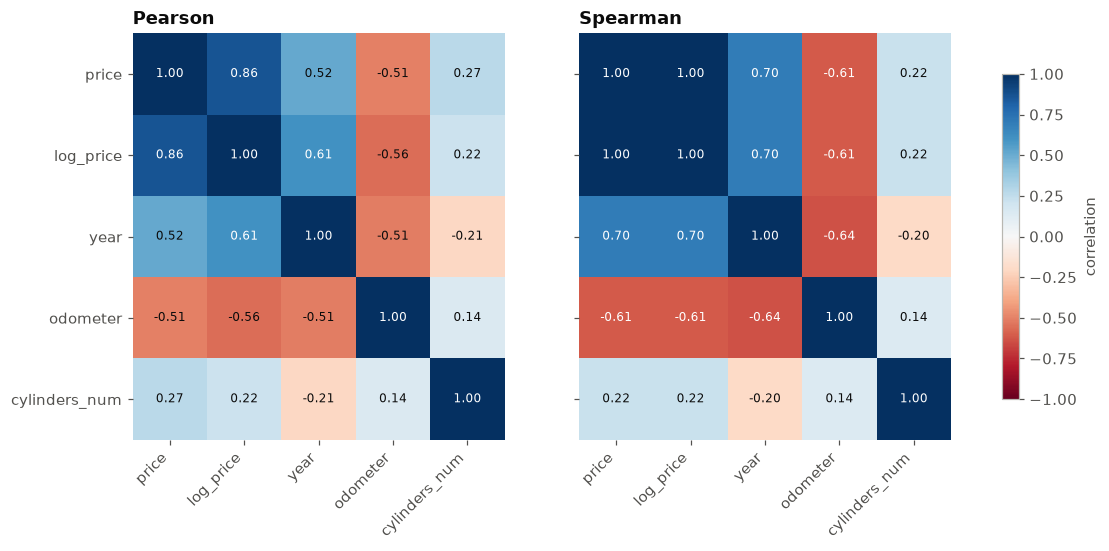

In [8]:
num = pd.DataFrame({
    "price": df["price"],
    "log_price": np.log1p(df["price"]),
    "year": df["year"],
    "odometer": df["odometer"],
    "cylinders_num": df["cylinders"].str.extract(r"(\d+)")[0].astype(float),
})

def heatmap(ax, table, fmt="{:.2f}", cmap="Blues", vmin=None, vmax=None, text_threshold=None):
    """Annotated heatmap; table is a DataFrame (NaN cells are left blank)."""
    im = ax.imshow(table.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(table.shape[1]), table.columns, rotation=45, ha="right")
    ax.set_yticks(range(table.shape[0]), table.index)
    ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
    lo, hi = im.get_clim()
    threshold = text_threshold if text_threshold is not None else lo + (hi - lo) * 0.6
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            v = table.values[i, j]
            if pd.notna(v):
                dark_cell = (abs(v) if cmap == "RdBu" else v) > abs(threshold)
                ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=8,
                        color="white" if dark_cell else INK)
    return im

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, method in zip(axes, ["pearson", "spearman"]):
    im = heatmap(ax, num.corr(method=method), cmap="RdBu", vmin=-1, vmax=1, text_threshold=0.6)
    ax.set_title(method.capitalize())
axes[1].set_yticklabels([])  # same order as the left panel
fig.colorbar(im, ax=axes, shrink=0.8, label="correlation")

## Association between all features (numeric and categorical)
A normal correlation only works for numbers, so this mixes three measures, all on a 0–1 scale:
- **numeric ↔ numeric:** |Spearman correlation|
- **categorical ↔ numeric:** correlation ratio η (how much knowing the category narrows the number down)
- **categorical ↔ categorical:** Cramér's V (bias-corrected)

The `log_price` row is how strongly each feature relates to the target. Bright cells between two *features* mean they carry overlapping information (e.g. `model` already tells you `manufacturer`, `type` and `drive`).

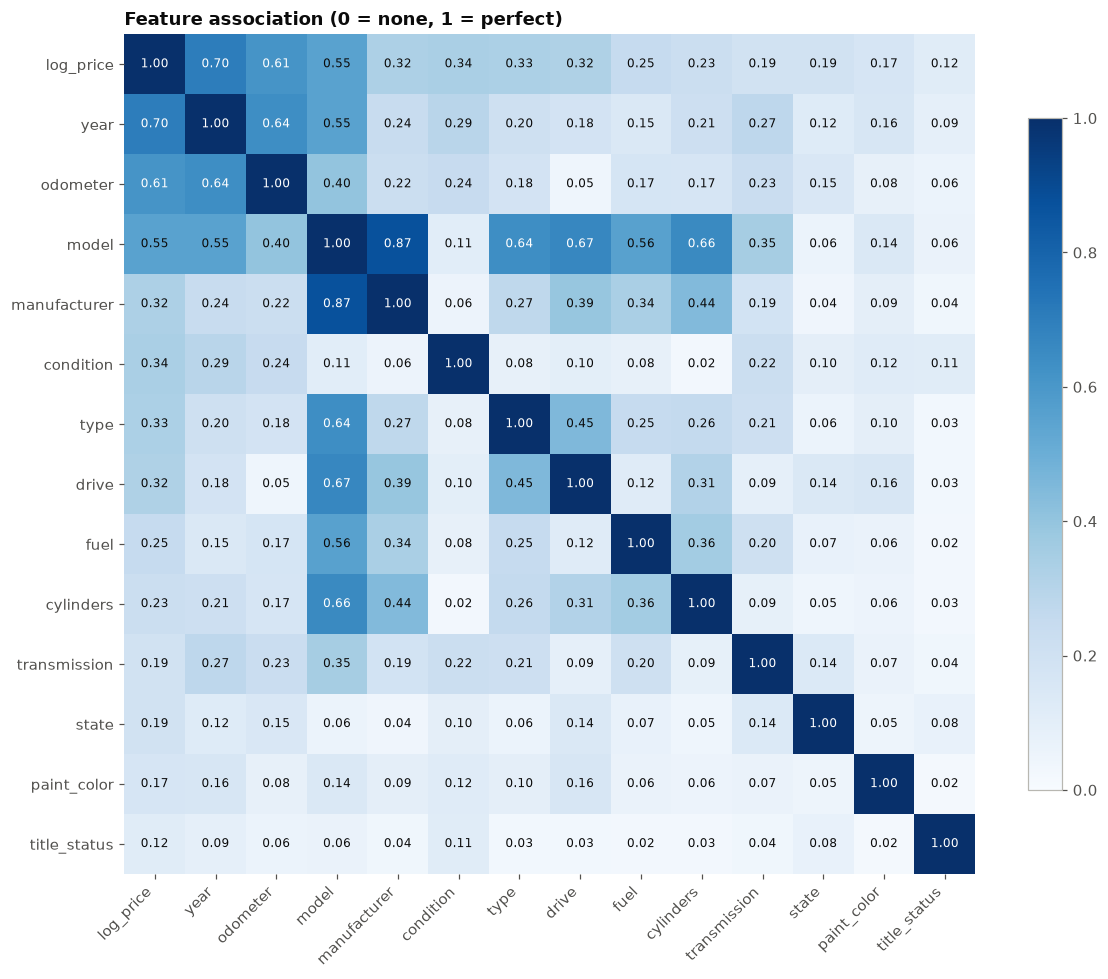

In [9]:
def correlation_ratio(cat, values):
    """eta: 0 = category tells nothing about the number, 1 = category fully determines it."""
    overall = values.mean()
    groups = values.groupby(cat)
    between = (groups.size() * (groups.mean() - overall) ** 2).sum()
    total = ((values - overall) ** 2).sum()
    return np.sqrt(between / total)

def cramers_v(a, b):
    table = pd.crosstab(a, b).values
    n = table.sum()
    expected = table.sum(1, keepdims=True) * table.sum(0, keepdims=True) / n
    chi2 = ((table - expected) ** 2 / expected).sum()
    r, k = table.shape
    phi2 = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))  # bias correction
    r_c, k_c = r - (r - 1) ** 2 / (n - 1), k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2 / max(1e-12, min(k_c - 1, r_c - 1)))

numeric_cols = ["log_price", "year", "odometer"]
cat_cols = ["model", "manufacturer", "condition", "type", "drive", "fuel", "cylinders",
            "transmission", "state", "paint_color", "title_status"]
data = df.assign(log_price=np.log1p(df["price"]))
cols = numeric_cols + cat_cols

assoc = pd.DataFrame(index=cols, columns=cols, dtype=float)
for i, a in enumerate(cols):
    for b in cols[i:]:
        if a == b:
            v = 1.0
        elif a in numeric_cols and b in numeric_cols:
            v = abs(data[a].corr(data[b], method="spearman"))
        elif a in numeric_cols or b in numeric_cols:
            cat, n = (b, a) if a in numeric_cols else (a, b)
            v = correlation_ratio(data[cat], data[n])
        else:
            v = cramers_v(data[a], data[b])
        assoc.loc[a, b] = assoc.loc[b, a] = v

fig, ax = plt.subplots(figsize=(11, 9))
im = heatmap(ax, assoc, vmin=0, vmax=1)
ax.set_title("Feature association (0 = none, 1 = perfect)")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()

## Year × mileage
Year and mileage are strongly linked (older cars have more miles), so they're worth seeing together. The left plot shows where listings sit; the right shows median price for each year/mileage combination (blank = fewer than 30 listings).

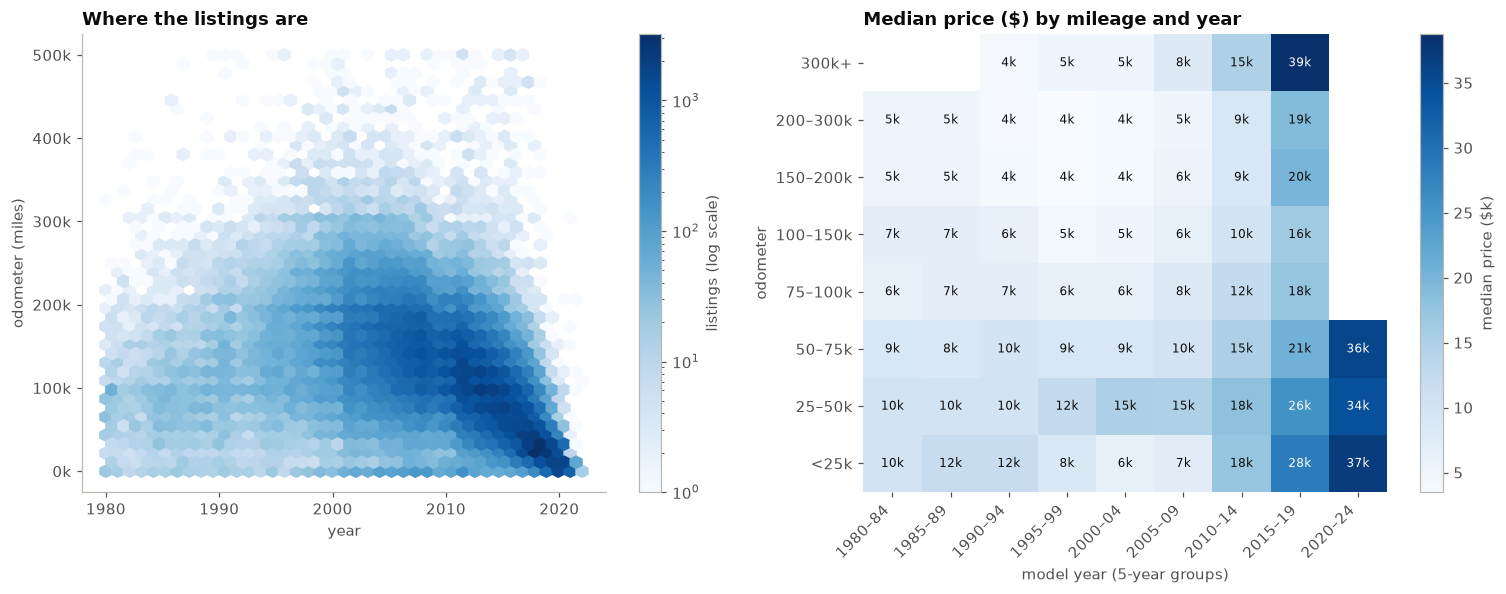

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

hb = axes[0].hexbin(df["year"], df["odometer"], gridsize=40, bins="log", cmap="Blues", mincnt=1)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x / 1000:,.0f}k"))
axes[0].set_xlabel("year")
axes[0].set_ylabel("odometer (miles)")
axes[0].set_title("Where the listings are")
axes[0].grid(False)
fig.colorbar(hb, ax=axes[0], label="listings (log scale)")

start = (df["year"] // 5 * 5).astype(int)
year_bin = start.astype(str) + "–" + (start + 4).astype(str).str[-2:]
odo_bin = pd.cut(df["odometer"], bins=[0, 25e3, 50e3, 75e3, 100e3, 150e3, 200e3, 300e3, 500e3],
                 labels=["<25k", "25–50k", "50–75k", "75–100k", "100–150k", "150–200k", "200–300k", "300k+"],
                 include_lowest=True)
g = df.groupby([odo_bin, year_bin], observed=True)["price"]
table = g.median().where(g.size() >= 30).unstack() / 1000
table = table.iloc[::-1]  # low mileage on top
im = heatmap(axes[1], table, fmt="{:.0f}k")
axes[1].set_title("Median price ($) by mileage and year")
axes[1].set_xlabel("model year (5-year groups)")
axes[1].set_ylabel("odometer")
fig.colorbar(im, ax=axes[1], label="median price ($k)")
plt.tight_layout()

## Vehicle type × condition
Median price for each combination (blank = fewer than 30 listings). Rows and columns are ordered by overall median price.

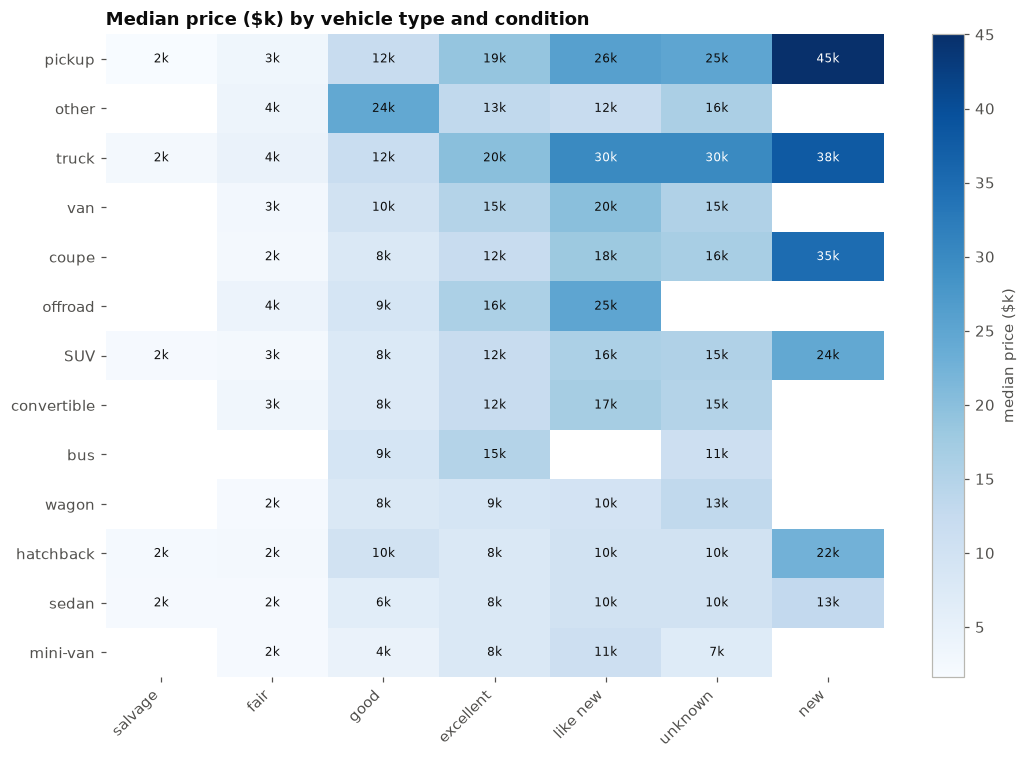

In [11]:
def median_table(row, col, min_count=30, rows=None):
    sub = df if rows is None else df[df[row].isin(rows)]
    g = sub.groupby([row, col])["price"]
    table = g.median().where(g.size() >= min_count).unstack() / 1000
    row_order = sub.groupby(row)["price"].median().sort_values(ascending=False).index
    col_order = sub.groupby(col)["price"].median().sort_values().index
    return table.reindex(index=row_order, columns=col_order).dropna(how="all")

fig, ax = plt.subplots(figsize=(10, 7))
im = heatmap(ax, median_table("type", "condition"), fmt="{:.0f}k")
ax.set_title("Median price ($k) by vehicle type and condition")
fig.colorbar(im, ax=ax, label="median price ($k)")
plt.tight_layout()

## Depreciation by manufacturer
Median price for the 15 most common manufacturers across model-year groups. Reading along a row shows how fast that brand loses value; trucks and luxury brands hold value differently from economy brands.

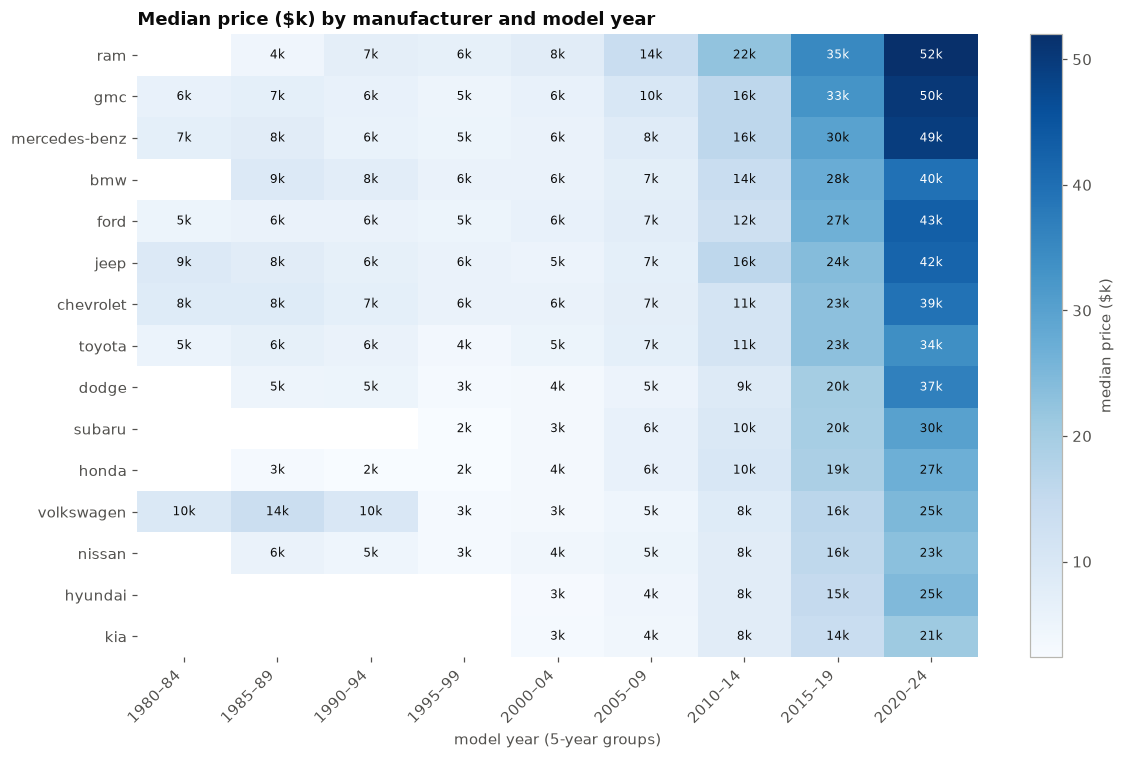

In [12]:
top_makers = df["manufacturer"].value_counts().head(15).index
start = (df["year"] // 5 * 5).astype(int)
data = df.assign(year_group=start.astype(str) + "–" + (start + 4).astype(str).str[-2:])
g = data[data["manufacturer"].isin(top_makers)].groupby(["manufacturer", "year_group"])["price"]
table = g.median().where(g.size() >= 30).unstack() / 1000
table = table.loc[table.iloc[:, -2].sort_values(ascending=False).index]  # sort by a recent year group

fig, ax = plt.subplots(figsize=(11, 7))
im = heatmap(ax, table, fmt="{:.0f}k")
ax.set_title("Median price ($k) by manufacturer and model year")
ax.set_xlabel("model year (5-year groups)")
fig.colorbar(im, ax=ax, label="median price ($k)")
plt.tight_layout()

## Drive × vehicle type
Does 4wd add value for every body type, or only some? Blank = fewer than 30 listings.

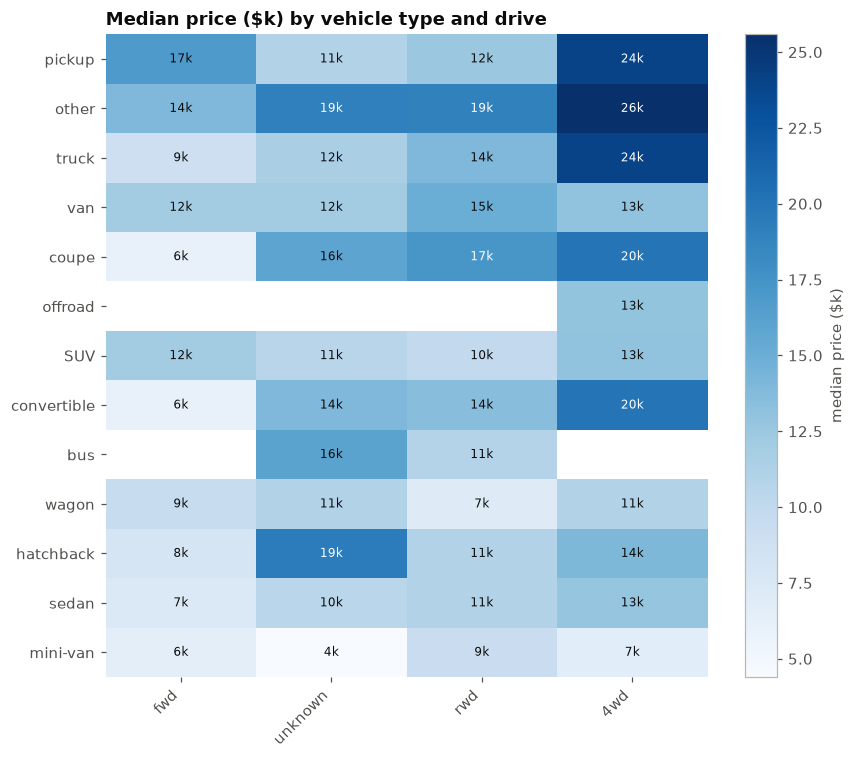

In [13]:
fig, ax = plt.subplots(figsize=(8, 7))
im = heatmap(ax, median_table("type", "drive"), fmt="{:.0f}k")
ax.set_title("Median price ($k) by vehicle type and drive")
fig.colorbar(im, ax=ax, label="median price ($k)")
plt.tight_layout()

# Iteration 2: feature engineering
Iteration 1 only used the columns that survived cleaning. The raw listings had more: the url, VIN, free-text description and lat/long. `data_cleaning.ipynb` now turns them into **listing fields** (`listing_fields`, in its iteration 2 section):
- `is_dealer` (from the url: craigslist `ctd` = dealer, `cto` = owner), `has_vin`, `desc_len`, `lat` / `long`
- keyword flags from the description: `needs_work`, `high_trim`, `lifted`, `diesel_words`, `one_owner`, ...

A raw price comparison would mostly show *which* cars each group sells (dealers sell newer cars). So the charts below compare each listing with **similar cars**: listings with the same year, manufacturer and model. +10% means priced 10% above similar cars.

In [14]:
ORANGE, RED, MID = "#eb6834", "#e34948", "#f0efec"
pct = mtick.FuncFormatter(lambda x, _: f"{x:+.0f}%")

# log-price minus the mean of cars with the same year, manufacturer and model (groups of 5+ only)
log_price = np.log1p(df["price"])
keys = [df["year"], df["manufacturer"], df["model"]]
similar = log_price.groupby(keys)
vs_similar = (log_price - similar.transform("mean")).where(similar.transform("size") >= 5)

def premium(mask):
    """% price gap vs similar cars: listings where mask is True vs where it's False."""
    return np.expm1(vs_similar[mask].mean() - vs_similar[~mask].mean()) * 100

dealer = df["is_dealer"] == 1
age = (2021 - df["year"]).clip(0, 30)
print(f"{vs_similar.notna().mean():.0%} of listings have 5+ similar cars")

96% of listings have 5+ similar cars


## Dealer vs private seller
Dealers ask more at every age. Part of that is reconditioning and warranties, part is dealer margin. For the fair-price meter this matters: the same car is "fair" at a different price depending on who sells it.

private listings: 35%   dealer premium vs similar cars: +13.9%


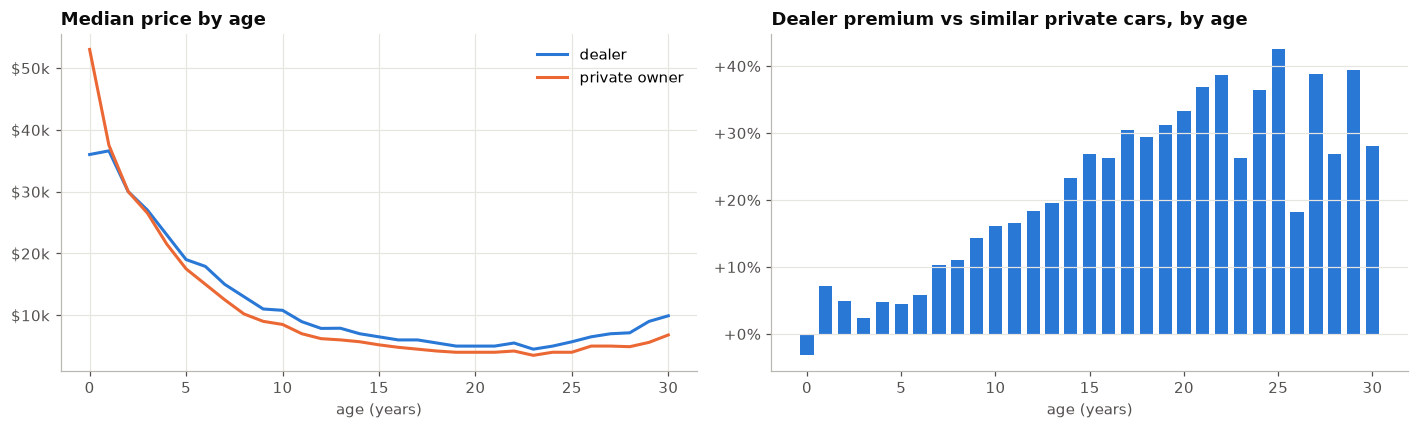

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for mask, color, label in [(dealer, ACCENT, "dealer"), (~dealer, ORANGE, "private owner")]:
    s = df[mask].groupby(age[mask])["price"].median()
    axes[0].plot(s.index, s.values, color=color, linewidth=2, label=label)
axes[0].yaxis.set_major_formatter(dollars)
axes[0].set_title("Median price by age")
axes[0].set_xlabel("age (years)")
axes[0].legend(frameon=False)

gap = vs_similar[dealer].groupby(age[dealer]).mean() - vs_similar[~dealer].groupby(age[~dealer]).mean()
axes[1].bar(gap.index, np.expm1(gap) * 100, color=ACCENT, width=0.7)
axes[1].yaxis.set_major_formatter(pct)
axes[1].set_title("Dealer premium vs similar private cars, by age")
axes[1].set_xlabel("age (years)")
axes[1].grid(axis="x", visible=False)
plt.tight_layout()
print(f"private listings: {(~dealer).mean():.0%}   dealer premium vs similar cars: {premium(dealer):+.1f}%")

## All listing fields at a glance
How much more (blue) or less (red) a listing costs than similar cars when it has each field. Keyword flags come from the description, so they catch things the structured columns can't: trim level, modifications, and "needs work".

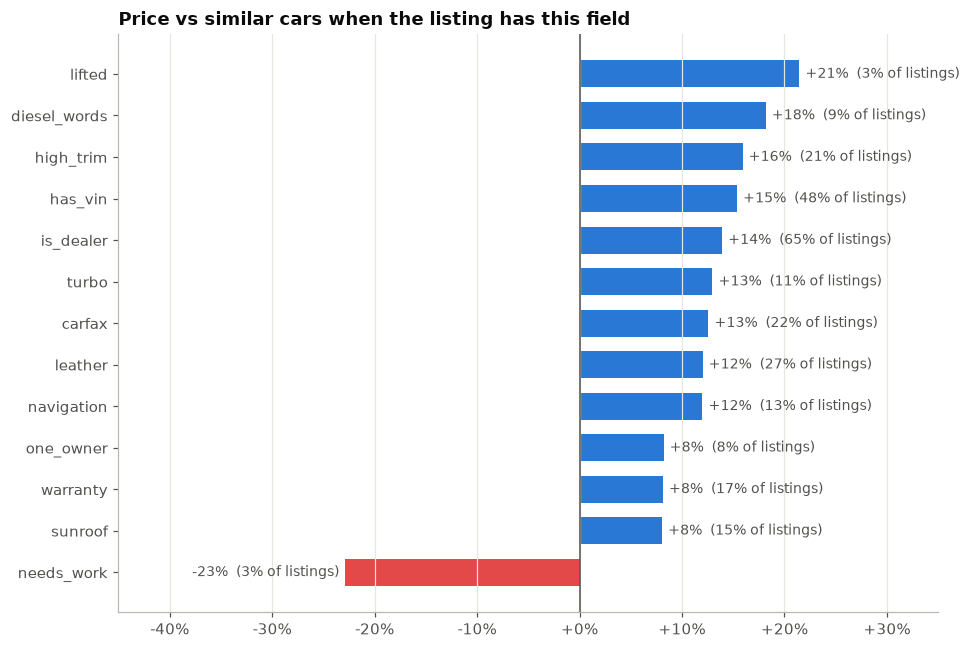

In [16]:
flags = ["is_dealer", "has_vin", "needs_work", "high_trim", "lifted", "diesel_words", "one_owner",
         "carfax", "warranty", "leather", "sunroof", "navigation", "turbo"]
effect = pd.DataFrame({
    "premium": [premium(df[f] == 1) for f in flags],
    "share": [df[f].mean() for f in flags],
}, index=flags).sort_values("premium")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(effect.index, effect["premium"], color=np.where(effect["premium"] < 0, RED, ACCENT), height=0.65)
ax.axvline(0, color=INK2, linewidth=1)
for y, (p, s) in enumerate(zip(effect["premium"], effect["share"])):
    ax.text(p + (0.6 if p >= 0 else -0.6), y, f"{p:+.0f}%  ({s:.0%} of listings)", va="center",
            ha="left" if p >= 0 else "right", color=INK2, fontsize=9)
ax.xaxis.set_major_formatter(pct)
ax.set_title("Price vs similar cars when the listing has this field")
ax.grid(axis="y", visible=False)
ax.set_xlim(-45, 35)
plt.tight_layout()

## Is `has_vin` just a dealer signal?
Dealers post VINs far more often, so the two overlap. The table shows price vs similar cars (%) for each combination: if `has_vin` still moves the price *within* dealers and *within* private sellers, it carries its own information (e.g. a seller willing to share the VIN has nothing to hide).

In [17]:
table = vs_similar.groupby([df["is_dealer"].map({1: "dealer", 0: "private"}),
                            df["has_vin"].map({1: "has VIN", 0: "no VIN"})]).mean().unstack()
(np.expm1(table) * 100).round(1)

has_vin,has VIN,no VIN
is_dealer,,
dealer,8.3,-3.4
private,-1.2,-9.2


## Description length
Longer descriptions go with higher prices. Split by seller, to check whether that's only because dealers write long boilerplate.

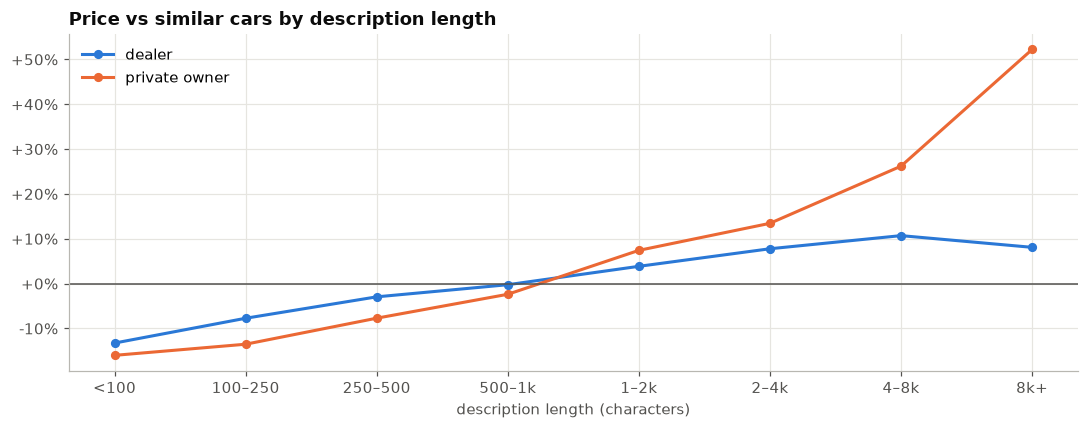

In [18]:
bins = [0, 100, 250, 500, 1000, 2000, 4000, 8000, np.inf]
labels = ["<100", "100–250", "250–500", "500–1k", "1–2k", "2–4k", "4–8k", "8k+"]
length_bin = pd.cut(df["desc_len"], bins=bins, labels=labels, right=False)

fig, ax = plt.subplots(figsize=(10, 4))
for mask, color, label in [(dealer, ACCENT, "dealer"), (~dealer, ORANGE, "private owner")]:
    s = np.expm1(vs_similar[mask].groupby(length_bin[mask], observed=True).mean()) * 100
    ax.plot(s.index.astype(str), s.values, color=color, linewidth=2, marker="o", markersize=5, label=label)
ax.axhline(0, color=INK2, linewidth=1)
ax.yaxis.set_major_formatter(pct)
ax.set_title("Price vs similar cars by description length")
ax.set_xlabel("description length (characters)")
ax.legend(frameon=False)
plt.tight_layout()

## Location beyond state
`state` is the only location feature in iteration 1. `lat` / `long` can pick up city vs rural and regional differences inside a state. Each hexagon is the average price vs similar cars for the listings in it (30+ listings, lower 48 states).

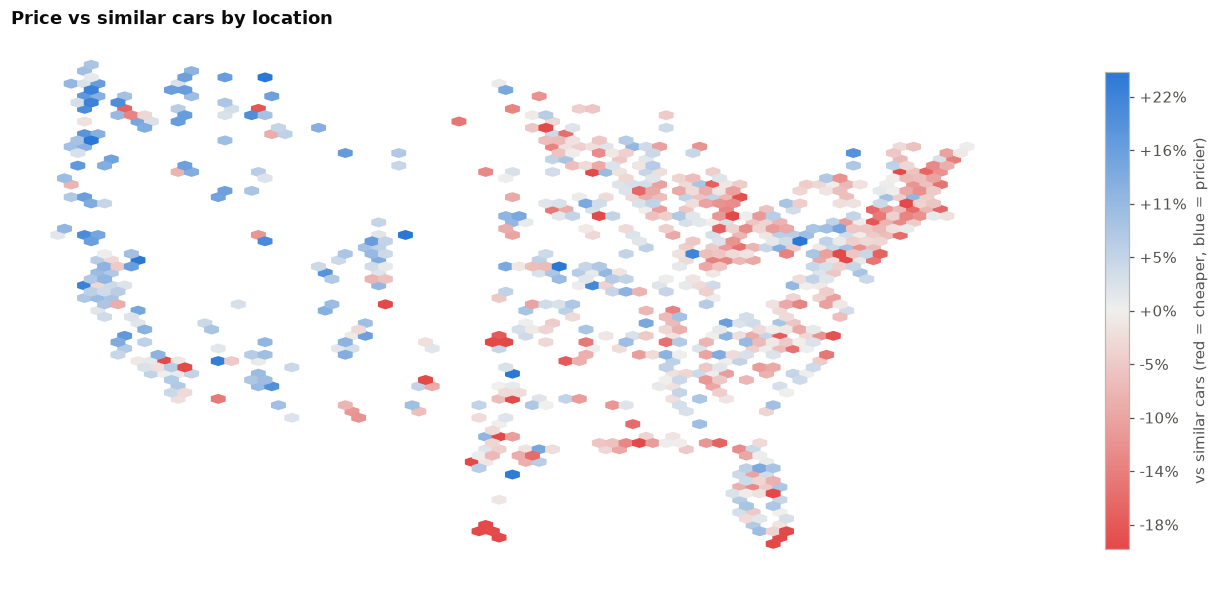

In [19]:
from matplotlib.colors import LinearSegmentedColormap

diverging = LinearSegmentedColormap.from_list("red_gray_blue", [RED, MID, ACCENT])
on_map = df["lat"].between(24, 50) & df["long"].between(-125, -66) & vs_similar.notna()

fig, ax = plt.subplots(figsize=(12, 6.5))
# averaged in log space (like vs_similar itself), shown as % on the colour bar
hb = ax.hexbin(df.loc[on_map, "long"], df.loc[on_map, "lat"], C=vs_similar[on_map],
               reduce_C_function=np.mean, gridsize=70, mincnt=30, cmap=diverging,
               vmin=np.log(0.8), vmax=-np.log(0.8))
ax.set_aspect(1.25)
ax.grid(False)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title("Price vs similar cars by location")
fig.colorbar(hb, ax=ax, shrink=0.7, format=mtick.FuncFormatter(lambda x, _: f"{np.expm1(x) * 100:+.0f}%"), label="vs similar cars (red = cheaper, blue = pricier)")
plt.tight_layout()

## Data-quality notes (not fixed yet)
- **Reposts:** ~8.2k listings share a VIN with another listing (the same car posted in several regions, sometimes at different prices). They survive dedupe because their state / price differ, and can land in both train and test, which makes the test score slightly optimistic. Candidate cleaning step: keep one listing per VIN.
- **Placeholder VINs** like `11111111111111111`.
- **Price in the text:** half of the descriptions contain a $ amount, often the asking price itself. That's why only keyword flags are taken from the text, never the raw text or numbers.
- **Not useful:** `county` is empty, `posting_date` covers one month (Apr–May 2021), `size` is 62% missing and adds almost nothing beyond `model`.

## Iteration 2 takeaways
- **Seller type** is the biggest structured addition: dealers ask +14% vs similar cars overall, and the gap grows with age (~+5% for 1–5 year old cars, +30–40% for 20+ year old ones).
- **`has_vin`** is not just a dealer proxy: it adds ~12% within dealers and ~8% within private sellers.
- **Description keywords** catch what the columns can't: `needs_work` −23%, `lifted` +21%, `diesel_words` +18%, `high_trim` +16%.
- **Description length** rises steadily with price, much more steeply for private sellers (a long private ad usually means a special car).
- **Location:** for the same car, the West is pricier and the Midwest / Northeast cheaper, with variation inside states that `state` alone can't capture.

These effects are *vs similar cars*, so they're signal the current features don't already have. Next: test them in `final_model.ipynb` (iteration 2, CV on the training set only) to see how much survives once all features are combined.